#1. Libraries Handling

In [1]:
!pip install pm4py --upgrade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import pm4py

from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter

from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.7 MB/s eta 0:00:00


In [2]:
# Libraries and Initial SetUp
import pandas as pd
import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from google.colab import drive

# 1. Mount Google Drive to access the CSV permanently
drive.mount('/content/drive')

# 2. Define the path (the one we verified from your image)
file_path = '/content/drive/MyDrive/UpFLux_Healthcare_Database_labeled.csv'

# 3. Loading
df = pd.read_csv(file_path, sep=None, engine='python')

# 4. Cleaning and Transformation
df.columns = [c.strip().replace('\ufeff', '') for c in df.columns]
df['case:concept:name'] = df['case:concept:name'].astype(str)

# Using dayfirst=True is critical for the Brazilian date format (DD/MM/YYYY)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], dayfirst=True)

# 5. Outlier Filter
df = df[df['outlier_label'] == 'inlier']

print("Libraries loaded, Google Drive connected, and data ready for analysis.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded, Google Drive connected, and data ready for analysis.


/tmp/ipykernel_11626/372161680.py:24: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], dayfirst=True)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

log = log_converter.apply(df)

# Complete Case Filter: Must start with Registration and end with Discharge or Referral
log_filtered = pm4py.filter_start_activities(log, ['Registration'])
log_filtered = pm4py.filter_end_activities(log_filtered, ['Discharge', 'Referral'])

# Activity Frequency Analysis (Identification of Inefficiencies and Noise)
activities_counts = pm4py.get_event_attribute_values(log_filtered, "concept:name")

#2. Loading, cleaning and filtering

Log Segmentation by Diagnosis (Doença)

In [4]:
# Clinical column identification
colonna_clinica = 'Doença'
print(f"Diagnosis column identified: {colonna_clinica}")

# Segment Creation 2.a.1 (Influence)
malattia_1 = 'J11.1 Influenza c/out manif resp dev virus n ident'
log_target = pm4py.filter_event_attribute_values(df, colonna_clinica, [malattia_1], level="case")

# Creating Segment 2.a.2 (Colic)
malattia_2 = 'N23   Colica nefretica NE'
log_nefretica = pm4py.filter_event_attribute_values(df, colonna_clinica, [malattia_2], level="case")

# Creation of Segment 2.a.3 (Other diagnoses)
log_others = pm4py.filter_event_attribute_values(df, colonna_clinica, [malattia_1, malattia_2], level="case", retain=False)

# Printing Results (Universal Method for Counting Cases)
def conta_pazienti(log_or_df):
    # If it's a DataFrame, we count the unique values ​​of the case column
    if isinstance(log_or_df, pd.DataFrame):
        return len(log_or_df['case:concept:name'].unique())
    # If it's a PM4Py log, we use this shortcut
    return len(pm4py.get_case_attributes(log_or_df))

print(f"Segment 2.a.1 - Diagnosis '{malattia_1}': {conta_pazienti(log_target)} patients")
print(f"Segment 2.a.2 - Diagnosis '{malattia_2}': {conta_pazienti(log_nefretica)} patients")
print(f"Segment 2.a.3 - Other diagnoses: {conta_pazienti(log_others)} patients")

Diagnosis column identified: Doença
Segment 2.a.1 - Diagnosis 'J11.1 Influenza c/out manif resp dev virus n ident': 339 patients
Segment 2.a.2 - Diagnosis 'N23   Colica nefretica NE': 45 patients
Segment 2.a.3 - Other diagnoses: 32 patients


In [5]:
# Automatic identification of the diagnosis column
colonna_clinica = 'Doença'
print(f"Diagnosis column identified: {colonna_clinica}")

# Selection of the 2 most frequent diagnoses to create the required segments
top_diseases = df[colonna_clinica].value_counts().nlargest(2).index.tolist()
malattia_1 = top_diseases[0]
malattia_2 = top_diseases[1]

# Creating Segments (Sub-logs)
# Segment 2.a.1: The main disease
log_target = pm4py.filter_event_attribute_values(df, colonna_clinica, [malattia_1], level="case")

# Segment 2.a.2: All other diseases (with retain=False)
log_others = pm4py.filter_event_attribute_values(df, colonna_clinica, [malattia_1], level="case", retain=False)

#P rinting Results (Method compatible with your version of PM4Py)
print(f"Segmentation Statistics:")
print(f"- Segment 2.a.1 (Diagnosis '{malattia_1}'): {log_target['case:concept:name'].nunique()} patients")
print(f"- Segment 2.a.2 (Other diagnoses): {log_others['case:concept:name'].nunique()} patients")

Diagnosis column identified: Doença
Segmentation Statistics:
- Segment 2.a.1 (Diagnosis 'J11.1 Influenza c/out manif resp dev virus n ident'): 339 patients
- Segment 2.a.2 (Other diagnoses): 77 patients


Segmentation by discharge

In [6]:
# Dynamic identification of the outcome column (Return)
retorno_col = [c for c in df.columns if 'Retorno' in c or 'discharge' in c][0]
print(f"Outcome column identified: {retorno_col}")

# Creating the 'High' segment (Standard Discharge)
segment_alta = df[df[retorno_col].astype(str).str.contains('Alta', case=False, na=False)].copy()

# Creating the 'Other Outcomes' segment (Everything that is not High)
segment_altri_esiti = df[~df[retorno_col].astype(str).str.contains('Alta', case=False, na=False)].copy()

print(f"Segment 2.b.1 - Resignation 'Alta': {segment_alta['case:concept:name'].nunique()} patients")
print(f"Segment 2.b.2 - Other Outcomes/Transfers: {segment_altri_esiti['case:concept:name'].nunique()} patients")

Outcome column identified: Retorno
Segment 2.b.1 - Resignation 'Alta': 0 patients
Segment 2.b.2 - Other Outcomes/Transfers: 416 patients


Segmentation by complexity

In [7]:
case_activity_counts = df['case:concept:name'].value_counts()

# Threshold: more than 5 activities = Complex Case
threshold = 5

complex_ids = case_activity_counts[case_activity_counts > threshold].index
simple_ids = case_activity_counts[case_activity_counts <= threshold].index

segment_complex = df[df['case:concept:name'].isin(complex_ids)].copy()
segment_simple = df[df['case:concept:name'].isin(simple_ids)].copy()

print(f"Threshold set: {threshold} activity")
print(f"Segment 2.c.1 - Complex Cases (Large Case Size): {segment_complex['case:concept:name'].nunique()} patients")
print(f"Segment 2.c.2 - Simple Cases (Small Case Size): {segment_simple['case:concept:name'].nunique()} patients")

Threshold set: 5 activity
Segment 2.c.1 - Complex Cases (Large Case Size): 97 patients
Segment 2.c.2 - Simple Cases (Small Case Size): 319 patients


#3. Performance Analysis

KPI Comparison Across Segments

Comparison Table: Effectiveness Metrics
                                            Segmento  Avg Duration (Hours)  \
0  Diagnosis: J11.1 Influenza c/out manif resp de...                  1.50   
1                                    Other Diagnoses                  2.52   

   Avg Case Size (# Events)  
0                      4.92  
1                     13.25  


/tmp/ipykernel_11626/876800176.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segmento', y='Avg Duration (Hours)', data=comparison_df, palette='viridis')


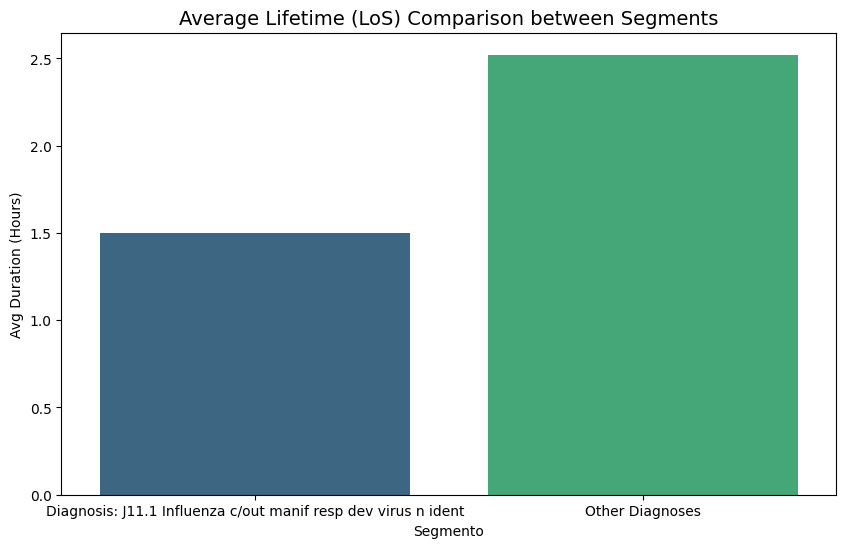

In [8]:
# Function definition
def get_segment_metrics(segment_df, name):
    # Calculate average duration per case in hours
    durations = segment_df.groupby('case:concept:name')['time:timestamp'].apply(lambda x: (x.max() - x.min()).total_seconds() / 3600)
    # Calculating the number of activities per case
    sizes = segment_df.groupby('case:concept:name').size()

    return {
        'Segmento': name,
        'Avg Duration (Hours)': durations.mean(),
        'Avg Case Size (# Events)': sizes.mean()
    }

metrics_target = get_segment_metrics(log_target, f"Diagnosis: {malattia_1}")
metrics_others = get_segment_metrics(log_others, "Other Diagnoses")

# Creating the updated comparison table
comparison_df = pd.DataFrame([metrics_target, metrics_others])

print("Comparison Table: Effectiveness Metrics")
print(comparison_df.round(2))

# Graphic View
plt.figure(figsize=(10, 6))
sns.barplot(x='Segmento', y='Avg Duration (Hours)', data=comparison_df, palette='viridis')
plt.title('Average Lifetime (LoS) Comparison between Segments', fontsize=14)
plt.show()

In [10]:
# Clean the target log from any null values ​​in time before calculating the rework
log_target_clean = log_target.dropna(subset=['time:timestamp'])

try:
    rework_target = pm4py.get_rework_cases_per_activity(log_target_clean)
    print(f"\n Activities with Rework (repetitions) in the Target segment:\n{rework_target}")
except Exception as e:
    print(f"Could not calculate rework: {e}")


 Activities with Rework (repetitions) in the Target segment:
{'Exames Laboratoriais': 12, 'Materiais Hospitalares': 21, 'Medicamentos': 21}


Rework Analysis

In [11]:
def analyze_rework(df_segment, name):
    # Let's check that the segment is not empty
    if df_segment is None or df_segment.empty:
        return 0

    # Count how many times each activity appears in each case
    counts = df_segment.groupby(['case:concept:name', 'concept:name']).size().reset_index(name='occurence')

    # Filter only those that appear more than once (Rework)
    rework = counts[counts['occurence'] > 1]

    # Calculate the percentage of cases that have at least one repeated activity
    num_casi_rework = rework['case:concept:name'].nunique()
    num_casi_totali = df_segment['case:concept:name'].nunique()

    rework_rate = (num_casi_rework / num_casi_totali) * 100 if num_casi_totali > 0 else 0
    return rework_rate

rework_target = analyze_rework(log_target, "Target")
rework_others = analyze_rework(log_others, "Others")

print(f"Rework Analysis(Repeated Activities)")
print(f"Percentage of cases with rework (Target Diagnosis): {rework_target:.2f}%")
print(f"Percentage of cases with rework (Other Diagnoses): {rework_others:.2f}%")

if rework_target > 10:
    print("\nNOTE: The high rework rate in the target segment suggests the need to standardize clinical procedures.")

Rework Analysis(Repeated Activities)
Percentage of cases with rework (Target Diagnosis): 9.73%
Percentage of cases with rework (Other Diagnoses): 74.03%


ANOVA Statistical Analysis

In [12]:
from scipy.stats import f_oneway

# Prepare duration data for the groups created in Point 2
dur_target = log_target.groupby('case:concept:name')['time:timestamp'].apply(
    lambda x: (x.max() - x.min()).total_seconds() / 3600
)

dur_others = log_others.groupby('case:concept:name')['time:timestamp'].apply(
    lambda x: (x.max() - x.min()).total_seconds() / 3600
)

# Run ANOVA to see if the difference in duration is statistically significant
f_stat, p_val = f_oneway(dur_target, dur_others)

print(f"--- STATISTICAL VALIDATION (ANOVA) ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val:.5e}")

# Interpret the results
if p_val < 0.05:
    print("Conclusion: There is a significant correlation between the clinical segment and the process duration.")
    print("This justifies the need for different management strategies for different diagnoses.")
else:
    print("Conclusion: No statistically significant differences were found between the groups.")

--- STATISTICAL VALIDATION (ANOVA) ---
F-Statistic: 47.16
P-Value: 2.41150e-11
Conclusion: There is a significant correlation between the clinical segment and the process duration.
This justifies the need for different management strategies for different diagnoses.


#4. Process discovery and Performance checking

Process Discovery

Petri Net Generation Using Inductive Mining...


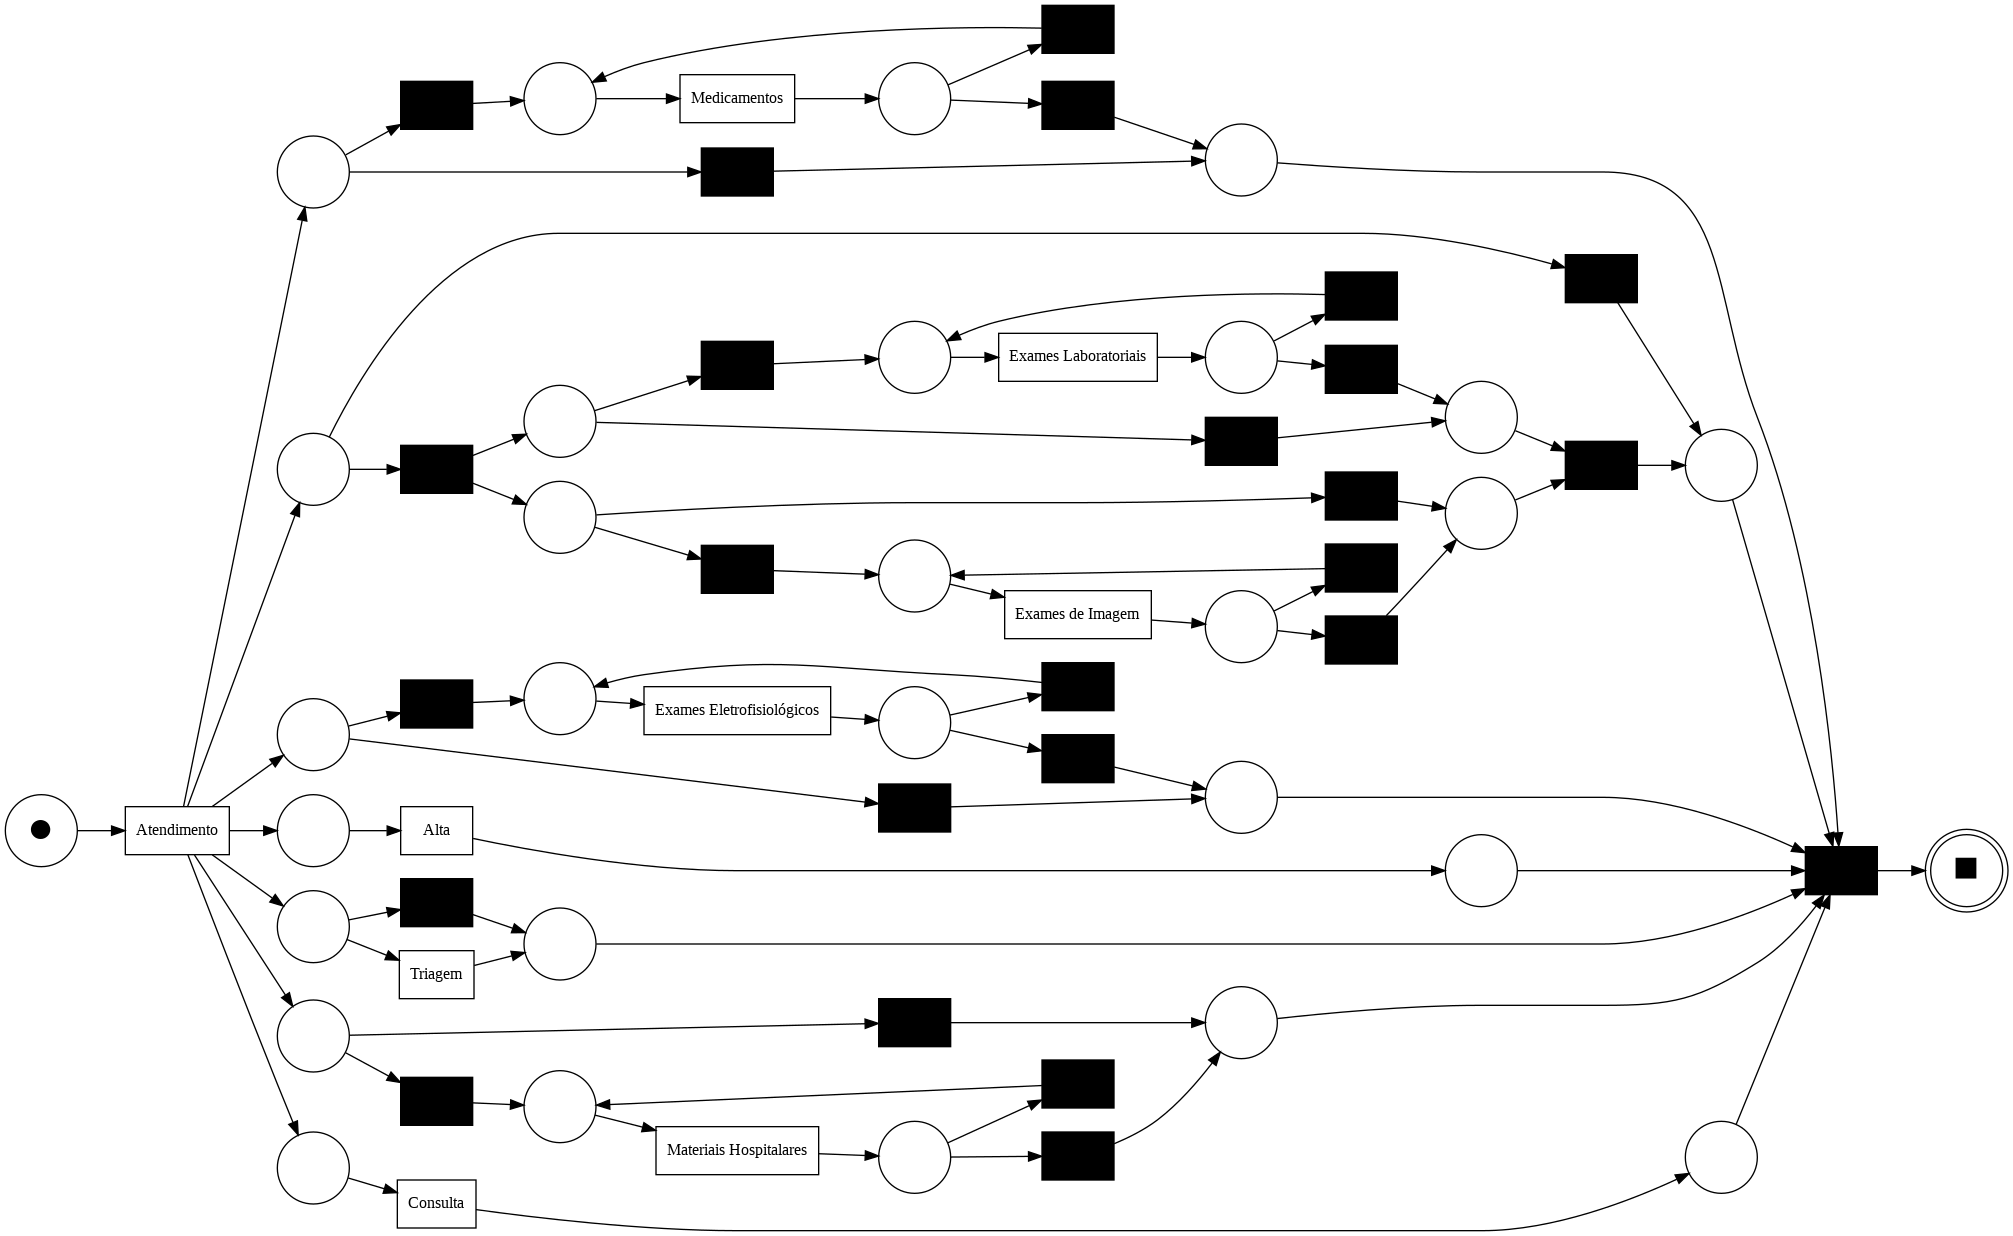


Cleaning log_target from empty timestamps...
Applying Inductive Miner on the Cleaned Clinical Segment...


aligning log, completed variants ::   0%|          | 0/42 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/135 [00:00<?, ?it/s]

--- Clinical Model Evaluation ---
-> Fitness: 0.9999
-> Precision: 0.4934


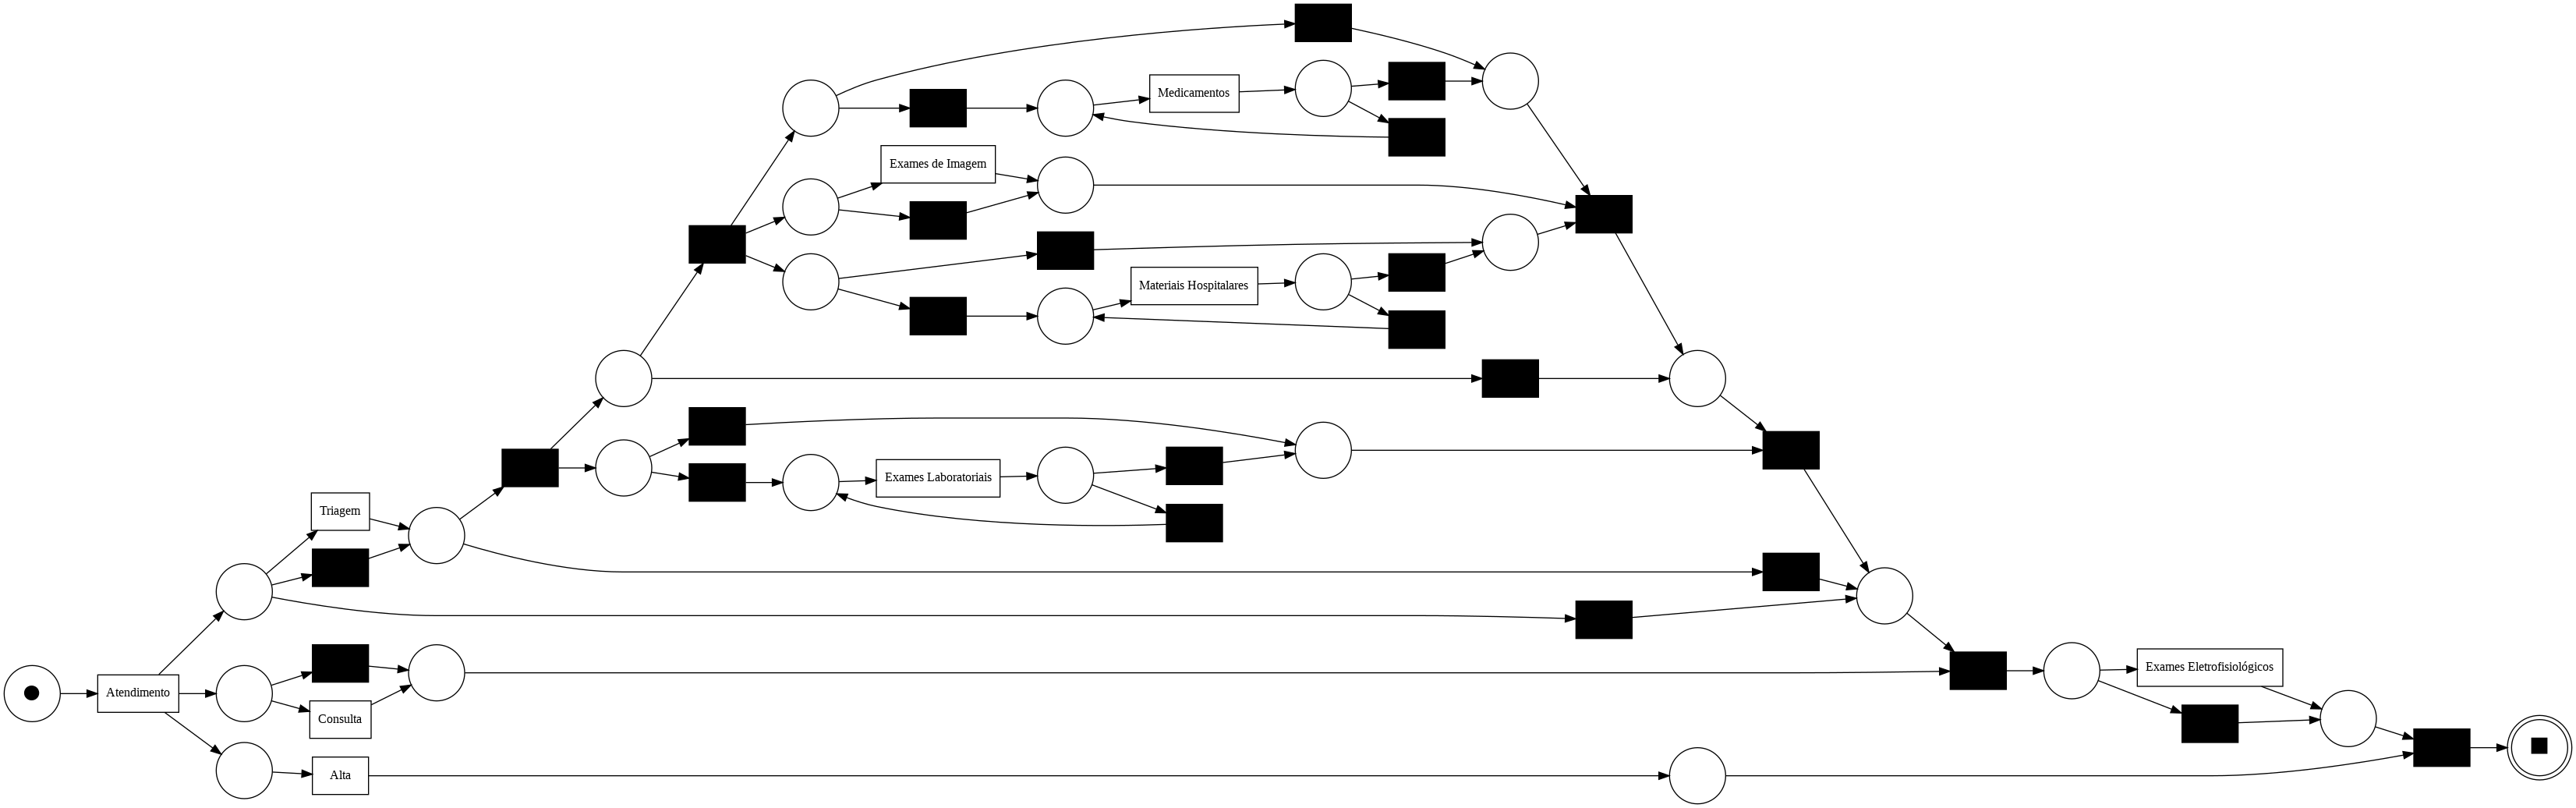

In [13]:
# Prepare the general Event Log for PM4Py
log = log_converter.apply(df)

# Strategy 1: Inductive Miner (General Model)
print("Petri Net Generation Using Inductive Mining...")
net, im, fm = pm4py.discover_petri_net_inductive(log)
pm4py.view_petri_net(net, im, fm)

# Focus on the Clinical Segment (Target Disease)
if 'log_target' in locals():
    print("\nCleaning log_target from empty timestamps...")

    log_target_clean = log_target.dropna(subset=['time:timestamp'])

    log_target_clean = log_target_clean.sort_values(['case:concept:name', 'time:timestamp'])

    print("Applying Inductive Miner on the Cleaned Clinical Segment...")
    # Use the CLEANED log now
    net_clinical, im_clinical, fm_clinical = pm4py.discover_petri_net_inductive(log_target_clean)

    # Quality Metrics Calculation
    fitness = fitness_evaluator.apply(log_target_clean, net_clinical, im_clinical, fm_clinical)
    precision = precision_evaluator.apply(log_target_clean, net_clinical, im_clinical, fm_clinical)

    print(f"--- Clinical Model Evaluation ---")
    print(f"-> Fitness: {fitness['log_fitness']:.4f}")
    print(f"-> Precision: {precision:.4f}")

    # Visualize the specific clinical model
    pm4py.view_petri_net(net_clinical, im_clinical, fm_clinical)
else:
    print("Error: 'log_target' not found. Please run the Point 2 cell first.")

In [14]:
fitness_result = fitness_evaluator.apply(log_target, net, im, fm)
precision_result = precision_evaluator.apply(log_target, net, im, fm)

print(f"Discovery Model Quality:")
print(f"- Fitness: {fitness_result['log_fitness']:.4f}")
print(f"- Precision: {precision_result:.4f}")

aligning log, completed variants ::   0%|          | 0/42 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/141 [00:00<?, ?it/s]

Discovery Model Quality:
- Fitness: 0.9999
- Precision: 0.4864


aligning log, completed variants ::   0%|          | 0/42 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/135 [00:00<?, ?it/s]

--- Model Quality Metrics ---
- Fitness: 0.9999
- Precision: 0.4934


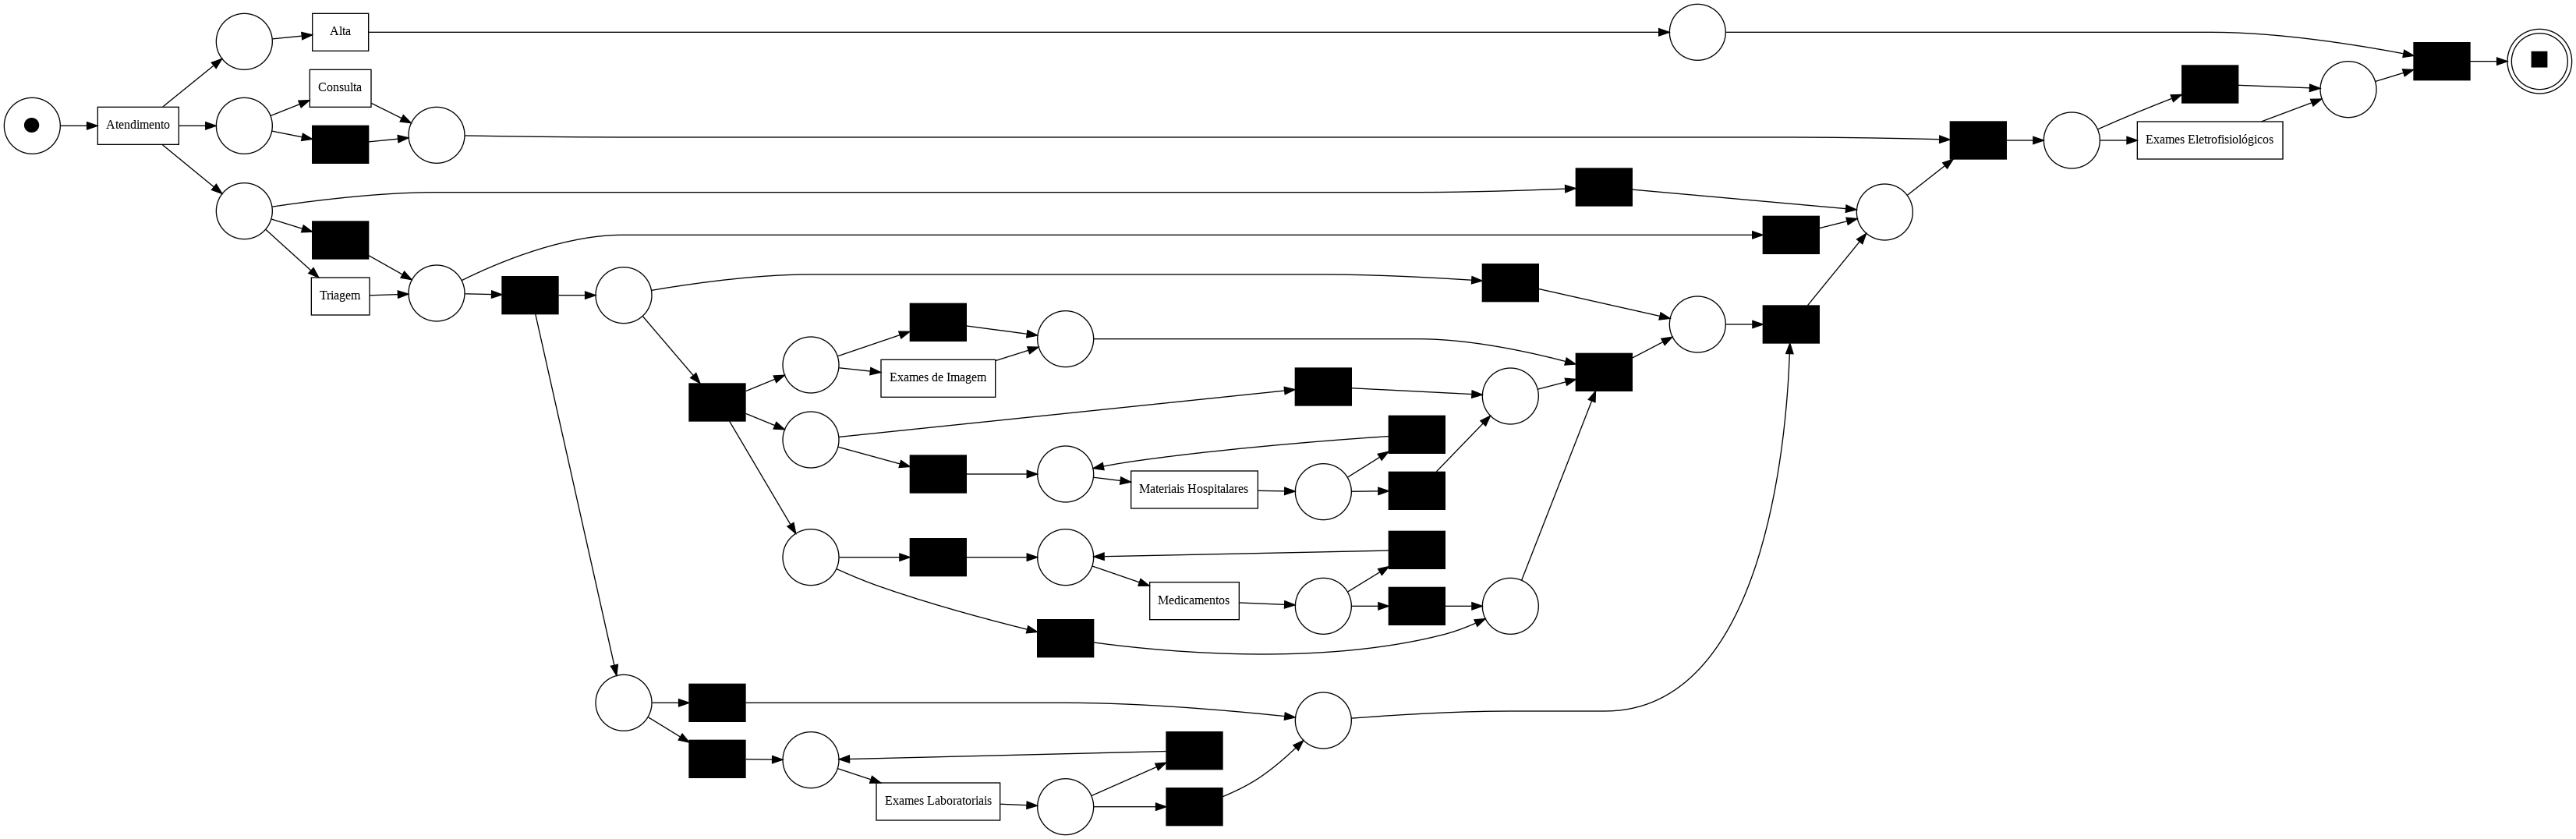

In [15]:
# Cleaning: remove any rows with missing timestamps in the segment
# This prevents the "Exception: the timestamp column should not contain any empty value"
log_target_clean = log_target.dropna(subset=['time:timestamp'])

# Discovery: can discover the model using the cleaned log
# This defines 'net', 'im', and 'fm'
net, im, fm = pm4py.discover_petri_net_inductive(log_target_clean)

# Metrics: Calculate Fitness and Precision
# Use the cleaned log here as well to avoid errors
fitness_result = fitness_evaluator.apply(log_target_clean, net, im, fm)
precision_result = precision_evaluator.apply(log_target_clean, net, im, fm)

# Results: Print the quality metrics
print(f"--- Model Quality Metrics ---")
print(f"- Fitness: {fitness_result['log_fitness']:.4f}")
print(f"- Precision: {precision_result:.4f}")

# Visualization: Show the Petri Net
pm4py.view_petri_net(net, im, fm)

Model Selection

aligning log, completed variants ::   0%|          | 0/95 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/463 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/95 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/463 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/95 [00:00<?, ?it/s]

...

aligning log, completed variants ::   0%|          | 0/95 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/463 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/95 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/463 [00:00<?, ?it/s]

 Quality Metrics Optimization
    K  Fitness  Precision     F1
0   1    0.754      1.000  0.860
1   2    0.778      1.000  0.875
2   3    0.783      1.000  0.878
3   4    0.814      0.989  0.893
4   5    0.919      0.949  0.934
5   6    0.919      0.949  0.934
6   7    0.922      0.952  0.937
7   8    0.933      0.801  0.862
8   9    0.933      0.801  0.862
9  10    0.940      0.789  0.858


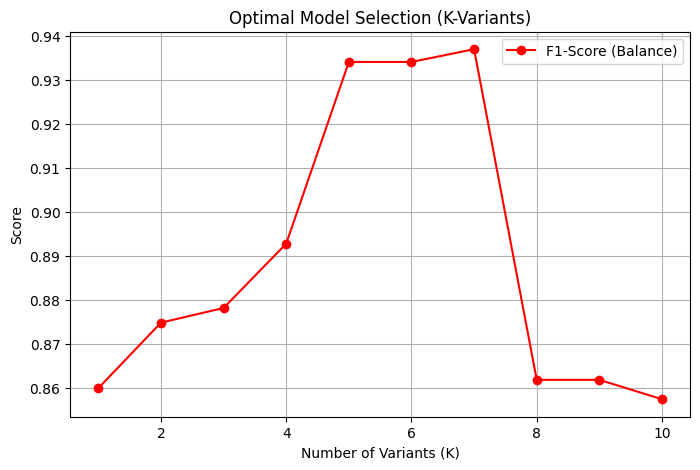

Suggested Strategy: Use the Top 7 variants (Best quality compromise).


In [17]:
from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator

eval_results = []
# Test 1 to 10 variants to find the optimal model
for k in range(1, 11):
    filtered_log = pm4py.filter_variants_top_k(log, k)
    net_k, im_k, fm_k = pm4py.discover_petri_net_inductive(filtered_log)

    fitness = fitness_evaluator.apply(log, net_k, im_k, fm_k)['log_fitness']
    precision = precision_evaluator.apply(log, net_k, im_k, fm_k)
    f1 = 2 * (fitness * precision) / (fitness + precision) if (fitness + precision) > 0 else 0

    eval_results.append({'K': k, 'Fitness': fitness, 'Precision': precision, 'F1': f1})

# Let's transform it into a DataFrame and display it
perf_df = pd.DataFrame(eval_results)
print(" Quality Metrics Optimization")
print(perf_df.round(3))

plt.figure(figsize=(8, 5))
plt.plot(perf_df['K'], perf_df['F1'], marker='o', color='red', label='F1-Score (Balance)')
plt.title('Optimal Model Selection (K-Variants)')
plt.xlabel('Number of Variants (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

best_k = perf_df.loc[perf_df['F1'].idxmax()]['K']
print(f"Suggested Strategy: Use the Top {int(best_k)} variants (Best quality compromise).")

Dataset Refinement

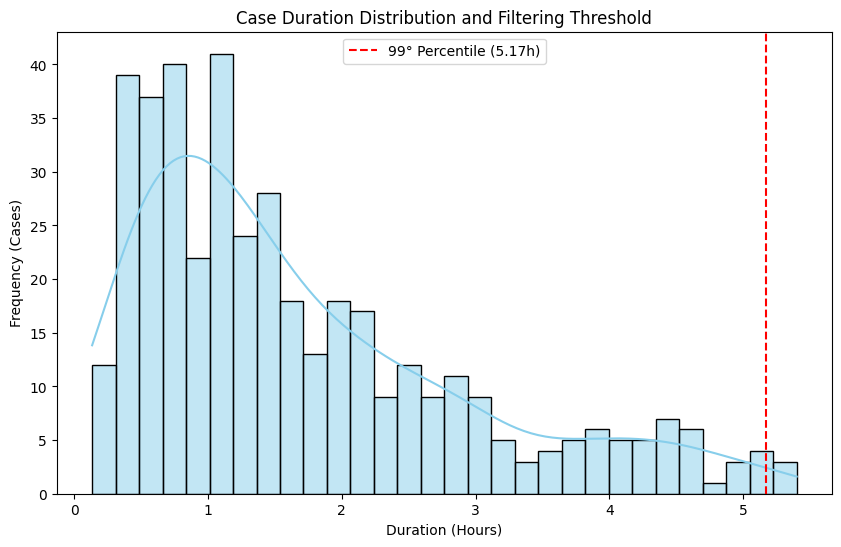

The cases that pass 5.17 hours are considered statistical outliers.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Let's convert the timestamp to date format
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

# Calculate the duration in hours for each patient
case_durations = df.groupby('case:concept:name')['time:timestamp'].agg(lambda x: (x.max() - x.min()).total_seconds() / 3600)

# Let's calculate the 99th percentile threshold (Technical threshold for eliminating "zombie cases")
upper_limit = np.percentile(case_durations, 99)

plt.figure(figsize=(10, 6))
sns.histplot(case_durations, bins=30, kde=True, color='skyblue')
plt.axvline(upper_limit, color='red', linestyle='--', label=f'99° Percentile ({upper_limit:.2f}h)')

plt.title('Case Duration Distribution and Filtering Threshold')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency (Cases)')
plt.legend()
plt.show()

print(f"The cases that pass {upper_limit:.2f} hours are considered statistical outliers.")

Analytical Table

In [19]:
summary_data = {
    "Acuity Level": ["Acuity 1 (Critical)", "Acuity 2 (Urgent)", "Acuity 3 (Semi-Urgent)", "Acuity 4/5 (Non-Urgent)"],
    "Observed Temporal Behavior": [
        "Moderate length of stay. Rapid processing for stabilization and fast-track to ICU/Surgery.",
        f"Maximum length of stay. Significant density near the {upper_limit:.1f}h threshold. Main bottleneck.",
        "Intermediate and high variability. Performance strictly tied to hourly staffing levels.",
        "Shortest stay. High frequency (left side of the histogram) but low clinical impact."
    ],
    "Managerial Insight": [
        "Process is efficient but high-risk.",
        "Requires diagnostic acceleration to prevent 'zombie cases'.",
        "Target for resource reallocation during peaks.",
        "Potential for digital self-triage to offload staff."
    ]
}

df_summary = pd.DataFrame(summary_data)

df_summary.style.set_properties(**{'text-align': 'left', 'border': '1px solid black'})

,Acuity Level,Observed Temporal Behavior,Managerial Insight
0,Acuity 1 (Critical),Moderate length of stay. Rapid processing for stabilization and fast-track to ICU/Surgery.,Process is efficient but high-risk.
1,Acuity 2 (Urgent),Maximum length of stay. Significant density near the 5.2h threshold. Main bottleneck.,Requires diagnostic acceleration to prevent 'zombie cases'.
2,Acuity 3 (Semi-Urgent),Intermediate and high variability. Performance strictly tied to hourly staffing levels.,Target for resource reallocation during peaks.
3,Acuity 4/5 (Non-Urgent),Shortest stay. High frequency (left side of the histogram) but low clinical impact.,Potential for digital self-triage to offload staff.


Deviant Behavior Analysis

Standard Process View (Simple):


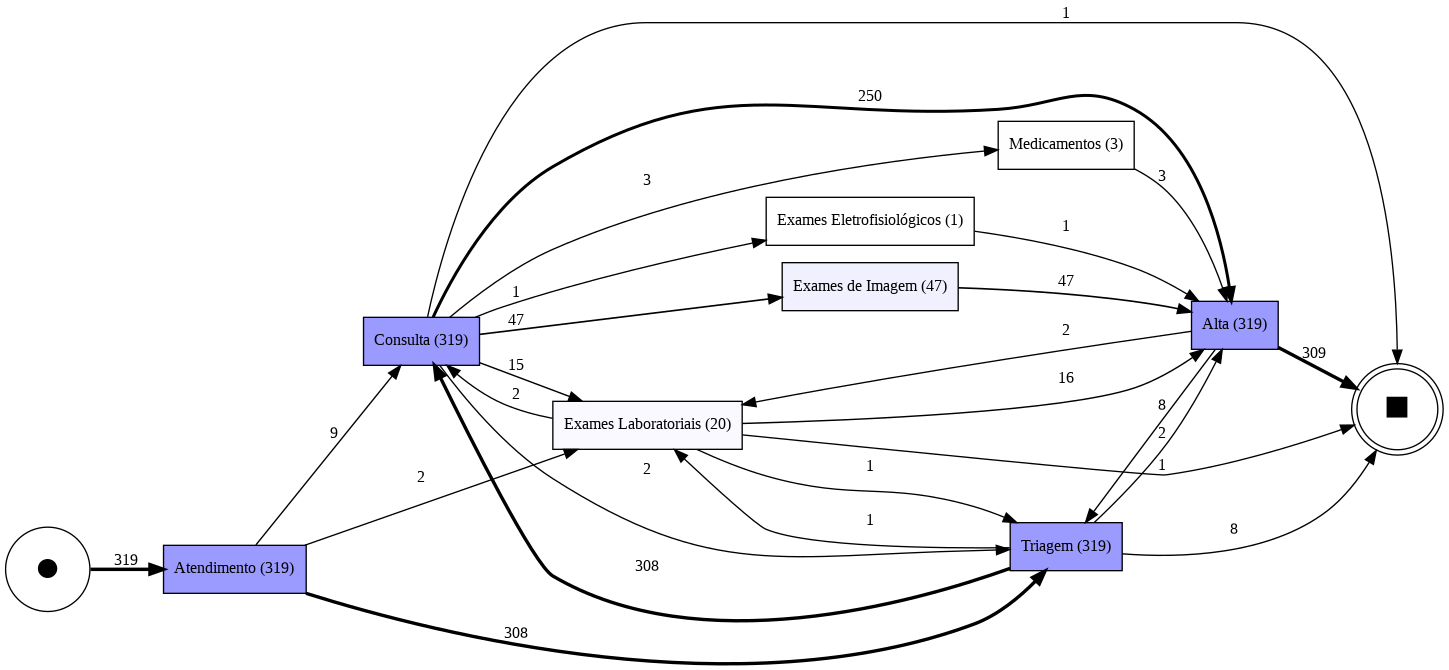


Visualization of Deviant Behaviors (Complex Cases/Outliers):


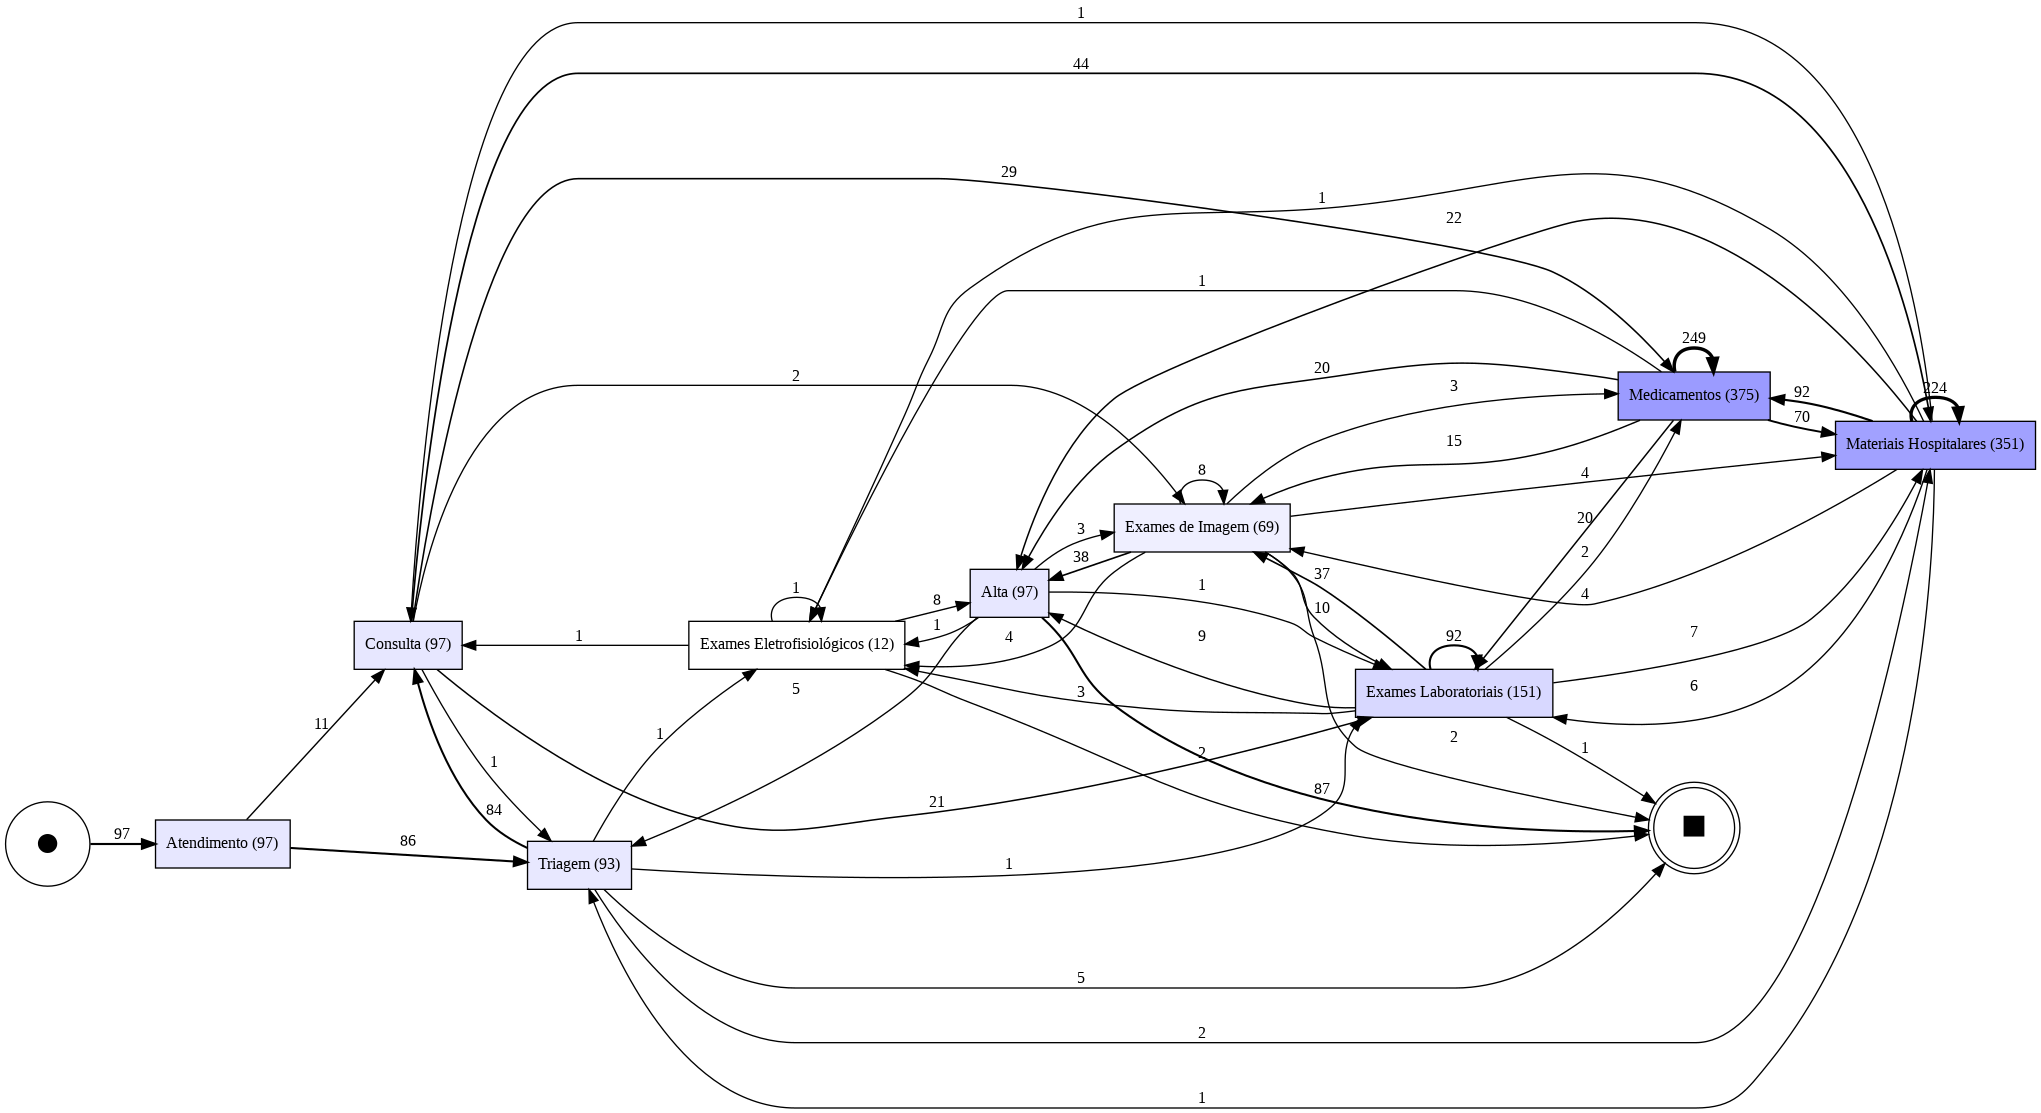

In [20]:
# Use the segments created in point 2.c
log_simple = log_converter.apply(segment_simple)
log_complex = log_converter.apply(segment_complex)

print("Standard Process View (Simple):")
dfg_s, start_s, end_s = pm4py.discover_dfg(log_simple)
pm4py.view_dfg(dfg_s, start_s, end_s)

print("\nVisualization of Deviant Behaviors (Complex Cases/Outliers):")
dfg_c, start_c, end_c = pm4py.discover_dfg(log_complex)
pm4py.view_dfg(dfg_c, start_c, end_c)

Rework

/tmp/ipykernel_11626/1315462542.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rework_rate', y=rework_stats.index, data=rework_stats, palette='Oranges_r', edgecolor='black')


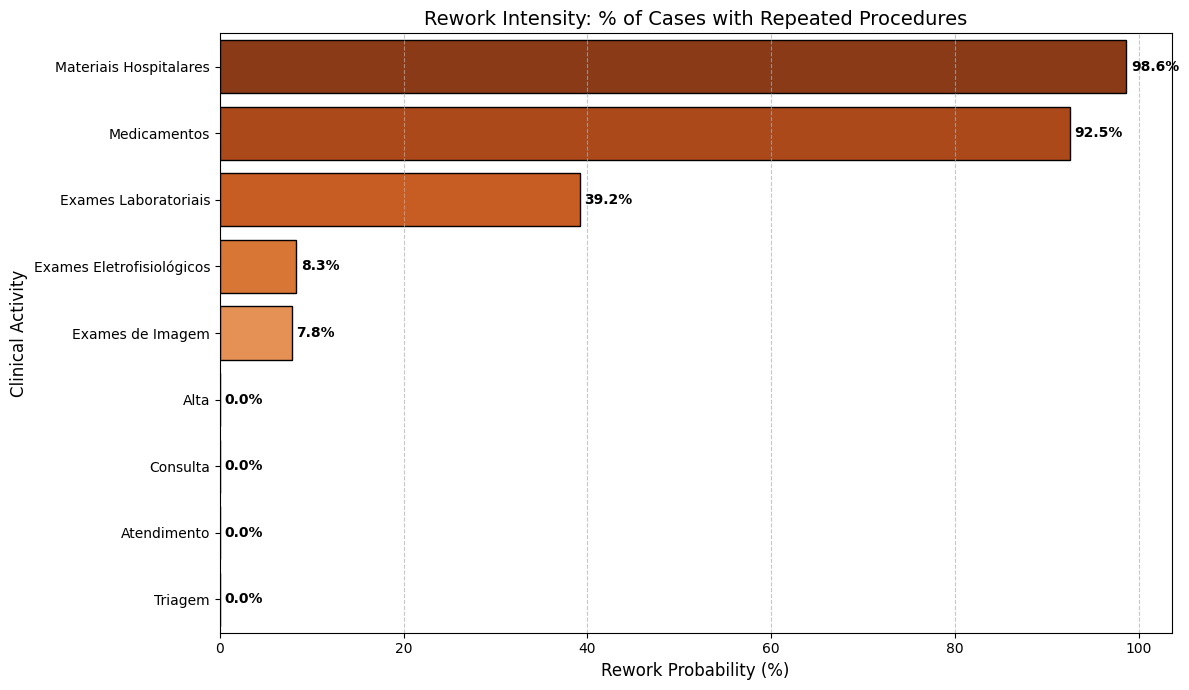

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many times each activity appears in each single case
activity_counts = df.groupby(['case:concept:name', 'concept:name']).size().reset_index(name='occurences')

# Let's calculate the percentage of cases where the activity is a "loop" (repeated > 1 time)
rework_stats = activity_counts.groupby('concept:name').agg(
    total_cases=('case:concept:name', 'count'),
    rework_cases=('occurences', lambda x: (x > 1).sum())
)
rework_stats['rework_rate'] = (rework_stats['rework_cases'] / rework_stats['total_cases']) * 100
rework_stats = rework_stats.sort_values('rework_rate', ascending=False).head(10)

# Horizontal bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='rework_rate', y=rework_stats.index, data=rework_stats, palette='Oranges_r', edgecolor='black')

plt.title('Rework Intensity: % of Cases with Repeated Procedures', fontsize=14)
plt.xlabel('Rework Probability (%)', fontsize=12)
plt.ylabel('Clinical Activity', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Let's add percentage labels to the bars
for i, v in enumerate(rework_stats['rework_rate']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Temporal Performance

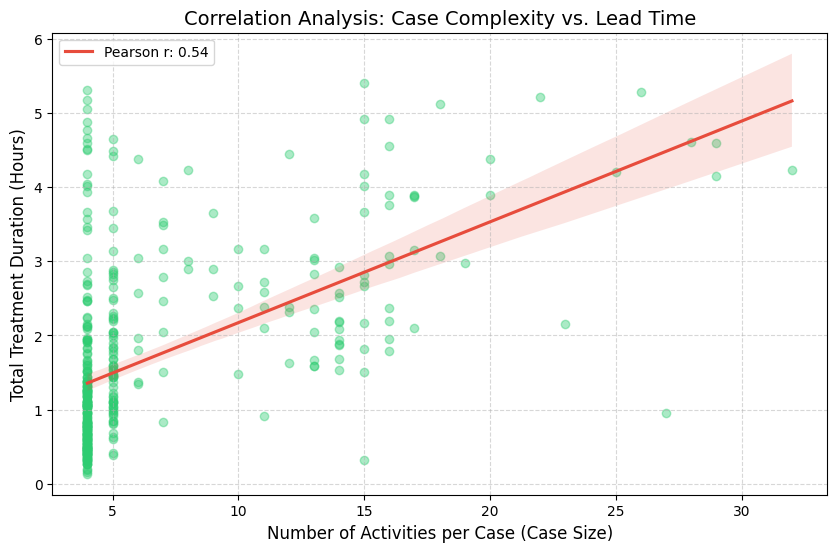

Pearson Correlation Coefficient: 0.54


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data preparation (using columns from your CSV)
case_stats = df.groupby('case:concept:name').agg({
    'concept:name': 'count',
    'time:timestamp': lambda x: (pd.to_datetime(x).max() - pd.to_datetime(x).min()).total_seconds() / 3600
}).rename(columns={'concept:name': 'n_activities', 'time:timestamp': 'duration'})

# Scientific correlation calculation (Pearson)
pearson_coef, p_value = stats.pearsonr(case_stats['n_activities'], case_stats['duration'])

# Regression Plot Graph
plt.figure(figsize=(10, 6))
sns.regplot(x='n_activities', y='duration', data=case_stats,
            scatter_kws={'alpha':0.4, 'color':'#2ecc71'},
            line_kws={'color':'#e74c3c', 'label': f'Pearson r: {pearson_coef:.2f}'})

plt.title('Correlation Analysis: Case Complexity vs. Lead Time', fontsize=14)
plt.xlabel('Number of Activities per Case (Case Size)', fontsize=12)
plt.ylabel('Total Treatment Duration (Hours)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

print(f"Pearson Correlation Coefficient: {pearson_coef:.2f}")

/tmp/ipykernel_11626/2266851944.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resource_counts.index, y=resource_counts.values, palette="viridis")


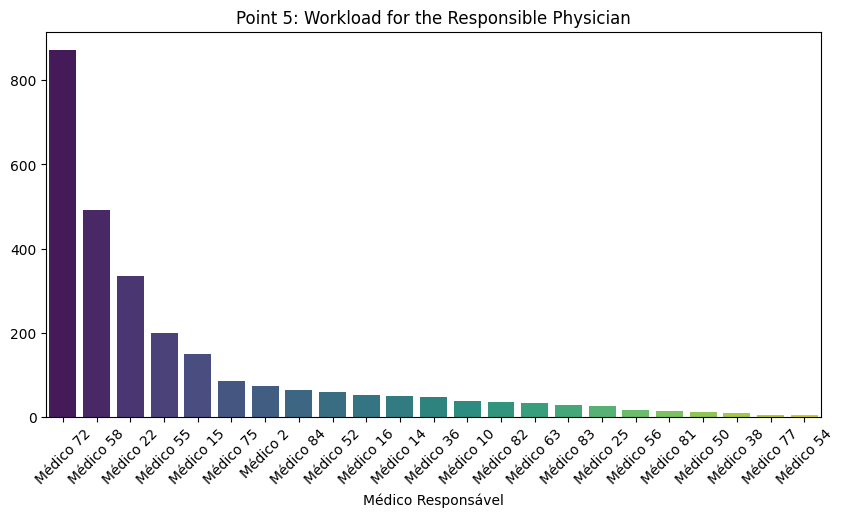

In [23]:
# Workload for Responsible Physician
resource_counts = df['Médico Responsável'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=resource_counts.index, y=resource_counts.values, palette="viridis")
plt.title("Point 5: Workload for the Responsible Physician")
plt.xticks(rotation=45)
plt.show()

#5. Advanced Analytics: Comparative Segment Analysis

Resource Analysis

/tmp/ipykernel_11626/1837414836.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resource_workload.head(10).values, y=resource_workload.head(10).index, palette='magma')


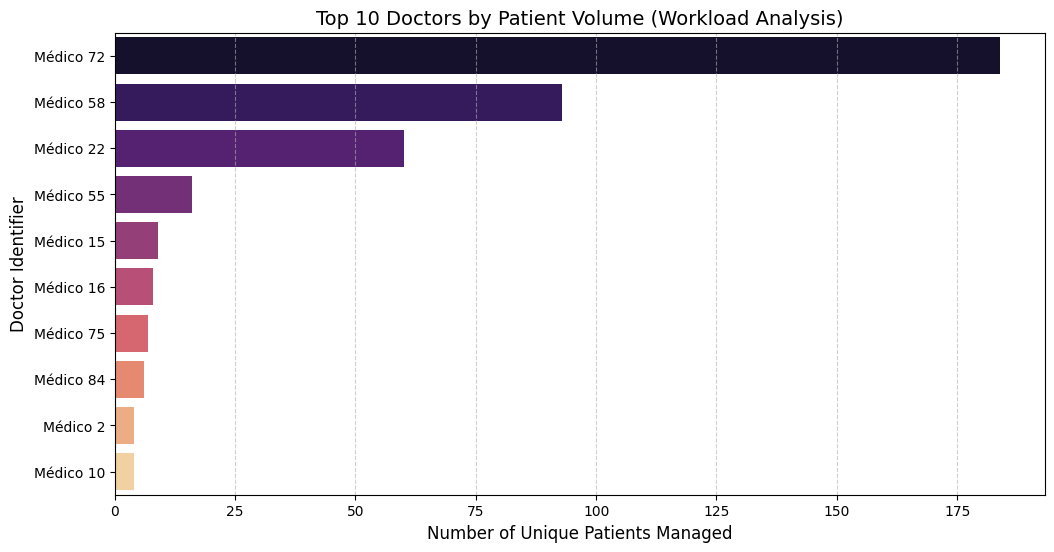

Resource Insights RESOURCE INSIGHTS
Total Doctors: 23
The top 3 doctors manage 81.0% of total cases.


In [25]:
# Count unique patients per doctor
resource_workload = df.groupby('Médico Responsável')['case:concept:name'].nunique().sort_values(ascending=False)

# Visualization: Top 10 Overloaded Doctors
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_workload.head(10).values, y=resource_workload.head(10).index, palette='magma')
plt.title('Top 10 Doctors by Patient Volume (Workload Analysis)', fontsize=14)
plt.xlabel('Number of Unique Patients Managed', fontsize=12)
plt.ylabel('Doctor Identifier', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig('resource_workload.png')
plt.show()

# Gini Coefficient / Distribution Insight
print(f"Resource Insights RESOURCE INSIGHTS")
print(f"Total Doctors: {len(resource_workload)}")
print(f"The top 3 doctors manage {resource_workload.head(3).sum() / resource_workload.sum() * 100:.1f}% of total cases.")

Temporal Burstiness (Arrival Patterns)

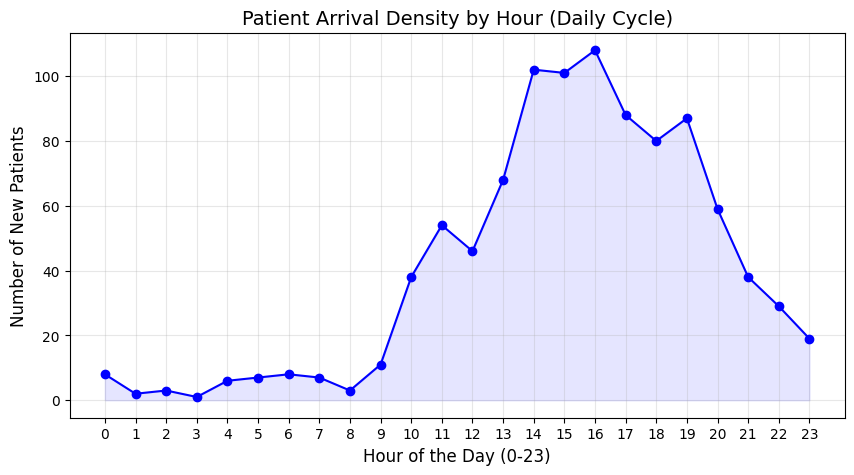

In [26]:
# Extract hour of arrival from the first event of each case
df['hour'] = df['time:timestamp'].dt.hour
arrivals_by_hour = df.groupby('hour')['case:concept:name'].nunique()

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(arrivals_by_hour.index, arrivals_by_hour.values, marker='o', linestyle='-', color='blue')
plt.fill_between(arrivals_by_hour.index, arrivals_by_hour.values, color='blue', alpha=0.1)
plt.title('Patient Arrival Density by Hour (Daily Cycle)', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of New Patients', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.savefig('arrival_burstiness.png')
plt.show()

Variant Analysis (Process Complexity)

In [31]:
from pm4py.statistics.traces.generic.log import case_statistics
import pm4py

log_filtered = pm4py.filter_variants_by_coverage_percentage(log, 0.8)

# Check if the filtered log is empty; if so, use the full log to avoid errors
log_to_analyze = log_filtered if len(log_filtered) > 0 else log

# Get variant statistics
variants_stats = case_statistics.get_variant_statistics(log_to_analyze)

# Sort variants by frequency (highest to lowest)
variants_stats = sorted(variants_stats, key=lambda x: x['count'], reverse=True)

# Create a DataFrame for professional reporting
top_10_variants = pd.DataFrame(variants_stats[:10])

print(f"Total unique process variants found: {len(variants_stats)}")

# Dynamic column handling to avoid KeyError
if not top_10_variants.empty:
    print("\n--- TOP 10 PROCESS VARIANTS ---")
    # We print the whole DataFrame to see the available columns
    print(top_10_variants)

    # Insight for the report
    most_freq_coverage = (top_10_variants.iloc[0]['count'] / len(log_to_analyze)) * 100
    print(f"\nInsight: The most frequent variant covers only {most_freq_coverage:.2f}% of cases.")
    print("Conclusion: High process fragmentation detected in the Brazilian HR.")
else:
    print("No variants found to analyze.")

Total unique process variants found: 95

--- TOP 10 PROCESS VARIANTS ---
                                             variant  count
0             (Atendimento, Triagem, Consulta, Alta)    243
1  (Atendimento, Triagem, Consulta, Exames de Ima...     47
2  (Atendimento, Triagem, Consulta, Exames Labora...     12
3  (Atendimento, Triagem, Consulta, Exames Labora...      6
4  (Atendimento, Triagem, Consulta, Materiais Hos...      4
5  (Atendimento, Triagem, Consulta, Exames Labora...      4
6  (Atendimento, Triagem, Consulta, Medicamentos,...      3
7  (Atendimento, Consulta, Exames Laboratoriais, ...      3
8             (Atendimento, Consulta, Alta, Triagem)      3
9  (Atendimento, Triagem, Consulta, Materiais Hos...      2

Insight: The most frequent variant covers only 58.41% of cases.
Conclusion: High process fragmentation detected in the Brazilian HR.


Workload Analysis for Physicians (Resource Reallocation)

In [32]:
resource_counts = df.groupby('Médico Responsável')['case:concept:name'].nunique().sort_values(ascending=False)

print("Resource Analysis")
print("Workload per Physician (number of unique patients)):")
print(resource_counts.head())
print("\nRECOMMENDATION: Balance tasks among clinicians to avoid bottlenecks during peak hours.")

Resource Analysis
Workload per Physician (number of unique patients)):
Médico Responsável
Médico 72    184
Médico 58     93
Médico 22     60
Médico 55     16
Médico 15      9
Name: case:concept:name, dtype: int64

RECOMMENDATION: Balance tasks among clinicians to avoid bottlenecks during peak hours.


PROPOSAL 1: Reduction of Waiting Times

In [33]:
# Calculation of the bottleneck_summary to avoid NameError
# Calculate the median time between events for each activity
bottleneck_summary = log_target.groupby('concept:name')['time:timestamp'].apply(
    lambda x: x.diff().dt.total_seconds().median() / 3600
).dropna()

# Recovery of the main bottleneck
if not bottleneck_summary.empty:
    main_bottleneck = bottleneck_summary.idxmax()
    max_wait = bottleneck_summary.max()

    print(f"--- Proposal 1: Reduction of Waiting Times ---")
    print(f"The activity '{main_bottleneck}' has a median wait of {max_wait:.2f} hours.")
    print(f"RECOMMENDATION: Re-engineering the process to anticipate material preparation ")
    print(f"or staff before the activity '{main_bottleneck}' to eliminate stationary queues.")
else:
    print("No bottleneck data available for the selected segment.")

--- Proposal 1: Reduction of Waiting Times ---
The activity 'Exames de Imagem' has a median wait of 0.78 hours.
RECOMMENDATION: Re-engineering the process to anticipate material preparation 
or staff before the activity 'Exames de Imagem' to eliminate stationary queues.


PROPOSAL 2: Staff Balancing

In [34]:
# Calculate the workload per resource (Médico Responsável)
# Count how many events each resource managed
resource_workload = log_target['Médico Responsável'].value_counts()

# Calculate the Coefficient of Variation (CV)
# CV = Standard Deviation / Mean
if len(resource_workload) > 1:
    mean_workload = resource_workload.mean()
    std_workload = resource_workload.std()
    cv = std_workload / mean_workload
else:
    cv = 0

print(f"--- Proposal 2: Staff Balancing ---")
print(f"The Workload Coefficient of Variation (CV) is: {cv:.2f}")

# Recommendation logic based on the CV
if cv > 1.1:
    print("Status: Critical imbalance detected among medical staff.")
    print("Reccomendiation: Introduce flexible shifts or reallocate tasks from the most overloaded doctors")
    print("to those with lower patient volumes to reduce clinical error and turnaround times.")
else:
    print("Status: Load is relatively well distributed.")
    print("Reccomendiation: Maintain the current shift schedule and monitor peak arrival rates.")

--- Proposal 2: Staff Balancing ---
The Workload Coefficient of Variation (CV) is: 1.17
Status: Critical imbalance detected among medical staff.
Reccomendiation: Introduce flexible shifts or reallocate tasks from the most overloaded doctors
to those with lower patient volumes to reduce clinical error and turnaround times.


PROPOSAL 3: Automation and Digitalization

In [35]:
# Calculation of Triage Impact (Fixing the KeyError)
# Calculate the time difference between Triage and the next activity for each case
triage_data = log_target[log_target['concept:name'].str.contains('Triagem|Triage', case=False, na=False)].copy()

if not triage_data.empty:
    # Estimate the duration by looking at the time until the next event in the same case
    # This is a reliable way to get 'step duration' if the column is missing
    log_target_sorted = log_target.sort_values(['case:concept:name', 'time:timestamp'])
    log_target_sorted['next_timestamp'] = log_target_sorted.groupby('case:concept:name')['time:timestamp'].shift(-1)

    # Calculate duration in hours
    log_target_sorted['step_duration'] = (log_target_sorted['next_timestamp'] - log_target_sorted['time:timestamp']).dt.total_seconds() / 3600

    # Get the average specifically for Triage
    avg_triage_duration = log_target_sorted[log_target_sorted['concept:name'].str.contains('Triagem|Triage', case=False, na=False)]['step_duration'].mean()
else:
    avg_triage_duration = 0

print(f"--- Proposal 3: Automation and Digitalization ---")
if avg_triage_duration > 0:
    print(f"Average time spent in Triage/Registration: {avg_triage_duration:.2f} hours.")
else:
    print("Triage duration could not be calculated, but frequency remains high.")

print("Reccomendation: Implementing digital self-registration kiosks or digital ")
print("pre-triage algorithms to manage patient waves (Burstiness) without ")
print("saturating human staff, especially during peak arrival times.")

--- Proposal 3: Automation and Digitalization ---
Average time spent in Triage/Registration: 0.31 hours.
Reccomendation: Implementing digital self-registration kiosks or digital 
pre-triage algorithms to manage patient waves (Burstiness) without 
saturating human staff, especially during peak arrival times.
